In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [15]:
DS_ROOT = Path(r"d:\Git_repository\result folder\data\processed\downsampled")
SIGNALS = ["SCL", "HR", "PVA", "TEMP", "MOTION"]
MAX_SECONDS = 240


In [16]:
def load_phase_csv(participant_id, phase_folder):
    fpath = DS_ROOT / phase_folder / f"{participant_id}.csv"
    if not fpath.exists():
        raise FileNotFoundError(f"File not found: {fpath}")
    df = pd.read_csv(fpath)
    if "sec" not in df.columns:
        raise ValueError(f"'sec' column missing in {fpath}")
    df = df[df["sec"] < MAX_SECONDS].copy()
    return df

def plot_participant(participant_id, med_group):
    """
    Plot stress vs meditation for a single participant.

    participant_id: e.g. "109"
    med_group:     "conventional", "vr_high", or "vr_low"
    """
    # Load data
    stress_df = load_phase_csv(participant_id, "stress")
    med_df    = load_phase_csv(participant_id, med_group)

    # One figure with subplots: top = stress, bottom = meditation
    n_sig = len(SIGNALS)
    fig, axes = plt.subplots(n_sig, 2, figsize=(10, 2.5 * n_sig), sharex=True)
    fig.suptitle(f"Participant {participant_id}: Stress vs {med_group}", fontsize=14)

    for i, sig in enumerate(SIGNALS):
        if sig not in stress_df.columns or sig not in med_df.columns:
            continue

        ax_stress = axes[i, 0]
        ax_med    = axes[i, 1]

        # Stress phase
        ax_stress.plot(stress_df["sec"], stress_df[sig], lw=1.2, color="tab:red")
        ax_stress.set_ylabel(sig)
        ax_stress.set_title(f"{sig} — Stress phase")
        ax_stress.grid(alpha=0.3)

        # Meditation phase (fixed color!)
        ax_med.plot(med_df["sec"], med_df[sig], lw=1.2, color="green")
        ax_med.set_title(f"{sig} — Meditation phase ({med_group})")
        ax_med.grid(alpha=0.3)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

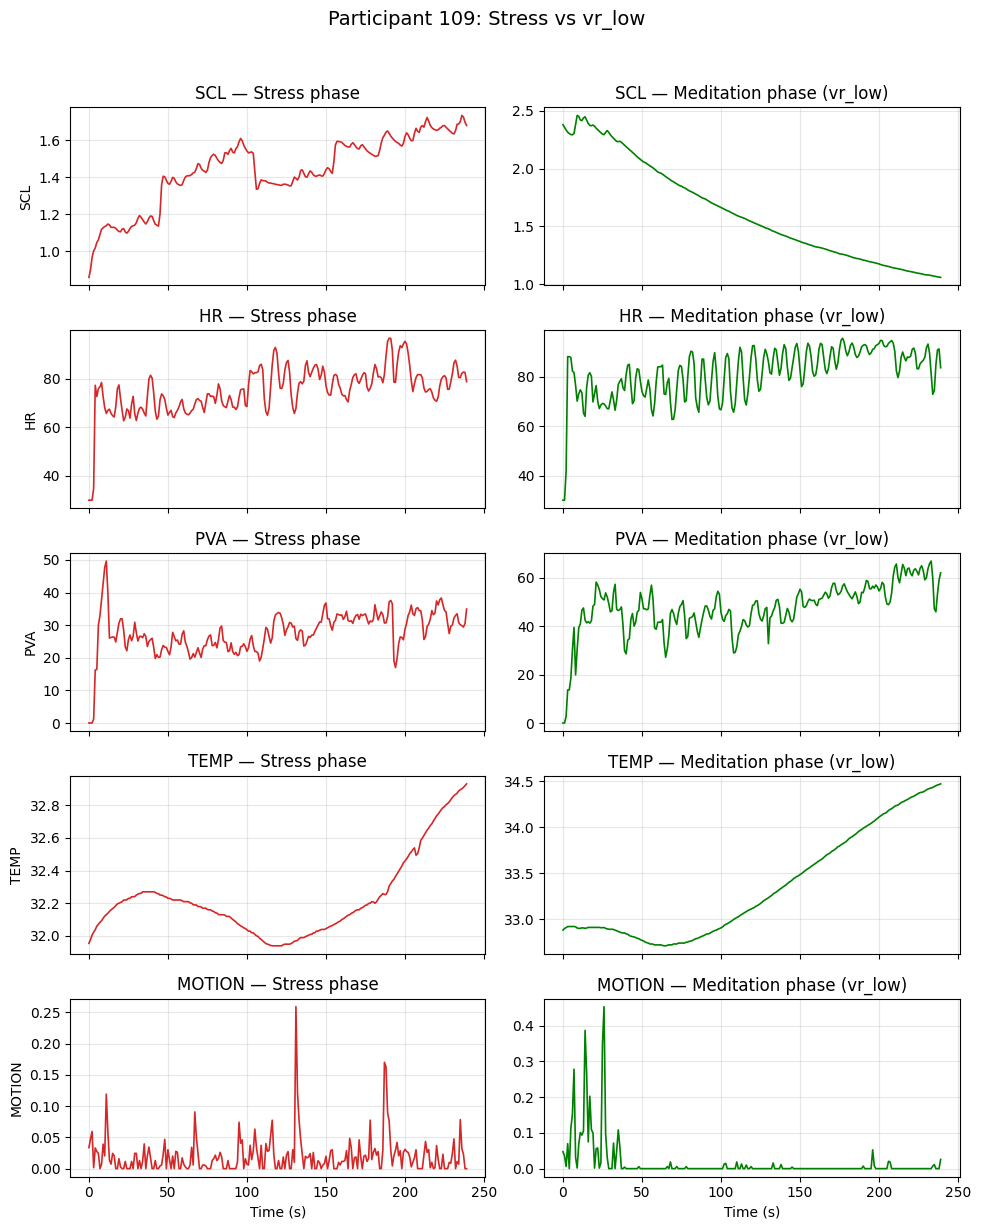

In [ ]:
plot_participant("109", "vr_low")
# or, if 109 is actually vr_high,conventional

